# MSCS 634 Advanced Data Mining Project
## Deliverable 4: Final Insights, Recommendations, and Consolidated Analysis

### Group Members

- Arun Gyawali
- Kashif Ali Syed
- Jiwon Jung
- Hanuman Sai Chanukya Srinivas Chilamkuri

**Dataset:** Online Shoppers Purchasing Intention Dataset  
**Course:** MSCS 634 – Advanced Big Data and Data Mining
**Date:** 07/26/2026

## Project Overview

This notebook consolidates the major methods and findings from Deliverables 1, 2, and 3 into one complete data-mining workflow. The project uses the Online Shoppers Purchasing Intention Dataset to examine online shopping behavior and purchasing outcomes.

The notebook includes:

1. Data validation and exploratory analysis
2. Feature engineering and regression modeling
3. Classification and hyperparameter tuning
4. K-Means clustering
5. Association rule mining
6. Integrated findings and practical recommendations
7. Ethical considerations, limitations, and future improvements

The cleaned dataset from Deliverable 1 is used throughout the notebook so that every phase is based on the same 12,205 shopping sessions.

## Dataset Selection and Justification

The Online Shoppers Purchasing Intention Dataset was selected because it contains more than 500 observations and more than 8–10 attributes. Each row represents one online shopping session, and the available features describe page visits, browsing durations, bounce rates, exit rates, page values, visitor information, seasonal information, traffic source, and purchasing outcome.

The dataset supports all required project tasks:

- **Regression:** Predict `ProductRelated_Duration`
- **Classification:** Predict the Boolean `Revenue` outcome
- **Clustering:** Group sessions with similar browsing behavior
- **Association rule mining:** Discover combinations of session behaviors associated with purchase

The same dataset was used throughout all four deliverables to preserve consistency.

## Required Libraries

The notebook uses Pandas and NumPy for data processing, Matplotlib and Seaborn for visualization, and Scikit-learn for modeling.

Install the required libraries when necessary:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn ipykernel
```

In [1]:
# Import the libraries used throughout the consolidated project.

import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    silhouette_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

# Part 1: Data Preparation and Exploratory Analysis

## Load the Cleaned Dataset

The cleaned dataset produced in Deliverable 1 is loaded directly. Deliverable 1 removed 125 exact duplicate records and capped only the most extreme values in the three duration columns. No missing, negative, or invalid rate values were found.

In [2]:
# Load the cleaned dataset created in Deliverable 1.
data = pd.read_csv("online_shoppers_cleaned.csv")

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (12205, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Validate the Consolidated Input

The following checks confirm that the saved dataset remains complete and suitable for the remaining analysis.

In [3]:
# Confirm the final dataset quality before modeling.
validation_summary = pd.DataFrame({
    "Check": [
        "Rows",
        "Columns",
        "Missing values",
        "Duplicate rows",
        "Negative numerical values"
    ],
    "Result": [
        data.shape[0],
        data.shape[1],
        int(data.isnull().sum().sum()),
        int(data.duplicated().sum()),
        int((data.select_dtypes(include=[np.number]) < 0).sum().sum())
    ]
})

validation_summary

,Check,Result
0,Rows,12205
1,Columns,18
2,Missing values,0
3,Duplicate rows,0
4,Negative numerical values,0


In [4]:
# Confirm that the bounded rate variables remain between 0 and 1.
bounded_columns = ["BounceRates", "ExitRates", "SpecialDay"]

range_validation = pd.DataFrame({
    "Minimum": data[bounded_columns].min(),
    "Maximum": data[bounded_columns].max(),
    "Outside 0 to 1": [
        int(((data[column] < 0) | (data[column] > 1)).sum())
        for column in bounded_columns
    ]
})

range_validation

,Minimum,Maximum,Outside 0 to 1
BounceRates,0.0,0.2,0
ExitRates,0.0,0.2,0
SpecialDay,0.0,1.0,0


### Data-Preparation Findings

The consolidated input contains **12,205 sessions and 18 columns**. The validation confirms that the cleaned file contains no missing values, duplicate rows, negative numerical values, or invalid bounded-rate values.

Using the cleaned file directly avoids repeating unnecessary preprocessing while preserving the decisions established in Deliverable 1.

## Purchase-Outcome Distribution

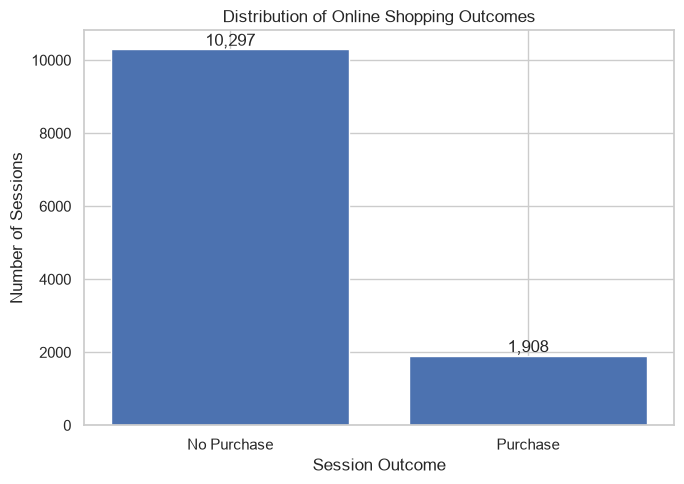

,Sessions,Percentage
Revenue,,
No Purchase,10297,84.37
Purchase,1908,15.63


In [5]:
# Create readable labels for the classification target.
purchase_labels = data["Revenue"].map({
    False: "No Purchase",
    True: "Purchase"
})

purchase_counts = purchase_labels.value_counts().reindex(
    ["No Purchase", "Purchase"]
)

plt.figure(figsize=(7, 5))
plt.bar(purchase_counts.index, purchase_counts.values)
plt.title("Distribution of Online Shopping Outcomes")
plt.xlabel("Session Outcome")
plt.ylabel("Number of Sessions")

for index, value in enumerate(purchase_counts.values):
    plt.text(index, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

purchase_summary = pd.DataFrame({
    "Sessions": purchase_counts,
    "Percentage": (
        purchase_counts / purchase_counts.sum() * 100
    ).round(2)
})

purchase_summary

### Purchase-Outcome Insight

The cleaned dataset contains **10,297 non-purchasing sessions (84.37%)** and **1,908 purchasing sessions (15.63%)**. Revenue is therefore an imbalanced classification target.

This imbalance is addressed later using stratified splitting, balanced class weights, F1 score, confusion matrices, and ROC-AUC rather than relying only on accuracy.

## Selected Behavioral Distributions

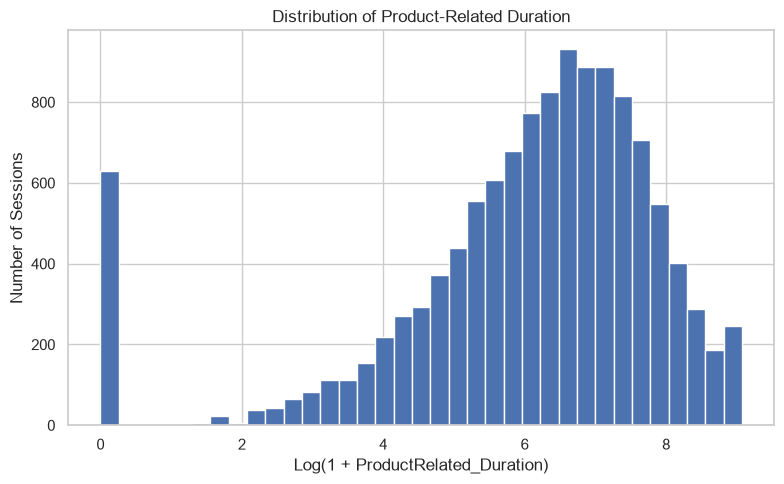

In [6]:
# Display the right-skewed ProductRelated_Duration distribution.
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(data["ProductRelated_Duration"]), bins=35)
plt.title("Distribution of Product-Related Duration")
plt.xlabel("Log(1 + ProductRelated_Duration)")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

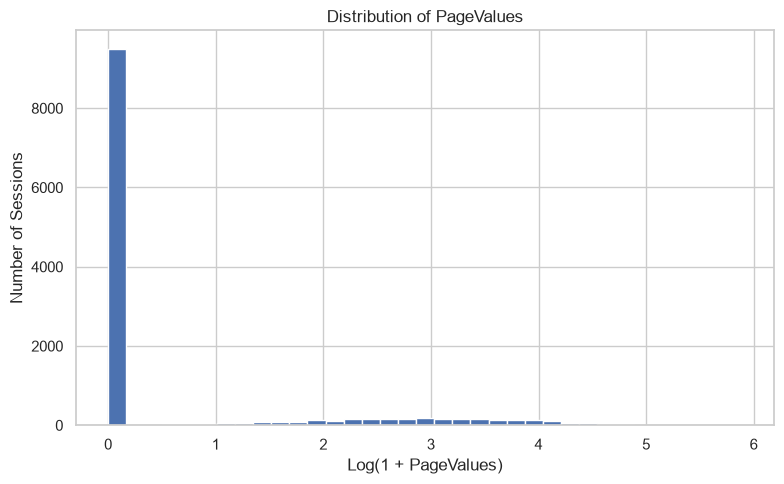

In [7]:
# Display the strongly zero-inflated PageValues distribution.
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(data["PageValues"]), bins=35)
plt.title("Distribution of PageValues")
plt.xlabel("Log(1 + PageValues)")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

### Distribution Insights

Product-related duration is right-skewed, although it behaves as a continuous variable and only a relatively small proportion of sessions have zero duration. This supported its selection as the regression target.

PageValues is strongly zero-inflated because most sessions did not contain positive page values. This was the main reason it was not selected as the regression target, although it remained an important classification feature.

## Correlation Analysis

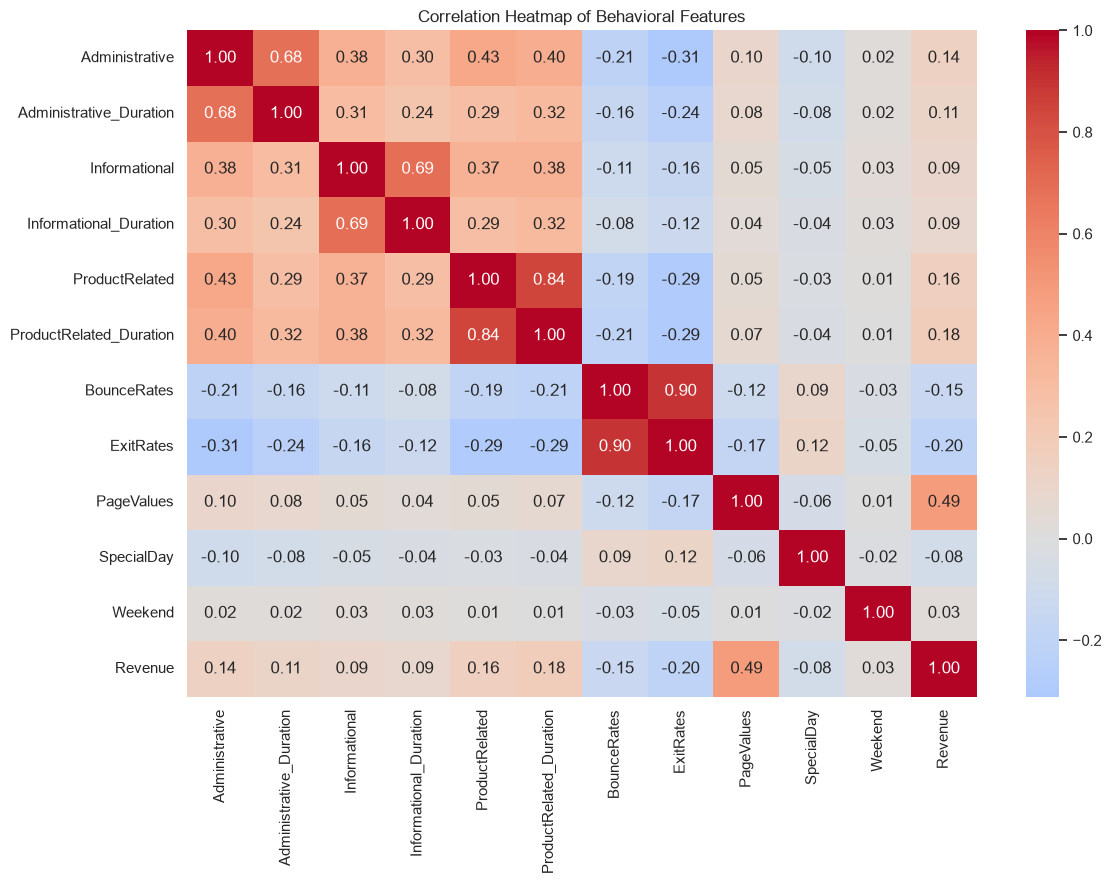

In [8]:
# Include only behavioral variables with meaningful quantitative values.
correlation_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Weekend",
    "Revenue"
]

correlation_data = data[correlation_columns].copy()
correlation_data["Weekend"] = correlation_data["Weekend"].astype(int)
correlation_data["Revenue"] = correlation_data["Revenue"].astype(int)

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of Behavioral Features")
plt.tight_layout()
plt.show()

In [9]:
# Display the correlations with Revenue separately.
revenue_correlations = (
    correlation_matrix["Revenue"]
    .drop("Revenue")
    .sort_values(ascending=False)
    .to_frame("Correlation with Revenue")
)

revenue_correlations.round(3)

,Correlation with Revenue
PageValues,0.492
ProductRelated_Duration,0.175
ProductRelated,0.156
Administrative,0.136
Administrative_Duration,0.110
Informational,0.094
Informational_Duration,0.087
Weekend,0.028
SpecialDay,-0.084
BounceRates,-0.145


### Correlation Insights

`PageValues` has the strongest positive correlation with Revenue at approximately **0.49**. `ProductRelated_Duration` and `ProductRelated` have smaller positive relationships with purchasing behavior.

`ExitRates` and `BounceRates` are negatively related to Revenue, showing that sessions with stronger abandonment behavior are less likely to produce purchases.

The heatmap also shows strong relationships between page counts and their corresponding durations, and between BounceRates and ExitRates. These relationships were considered during feature engineering and model selection.

## Engagement by Purchase Outcome

In [10]:
# Compare average engagement between purchasing and non-purchasing sessions.
engagement_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

engagement_summary = (
    data.groupby("Revenue")[engagement_columns]
    .mean()
    .rename(index={False: "No Purchase", True: "Purchase"})
    .round(3)
)

engagement_summary

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues
Revenue,,,,,,,,,
No Purchase,2.143,70.268,0.457,26.753,29.05,1047.250,0.023,0.046,2.000
Purchase,3.394,113.451,0.786,51.970,48.21,1797.834,0.005,0.020,27.265


### Engagement Insights

Purchasing sessions show greater engagement than non-purchasing sessions. They contain more page visits, longer browsing durations, substantially higher PageValues, and lower bounce and exit rates.

These findings guided the feature-engineering choices and supported the later classification and association-rule results.

# Part 2: Feature Engineering and Regression Modeling

## Feature Engineering

Five behavioral features are created to summarize browsing depth, non-product activity, abandonment behavior, and engagement. None of these features directly uses `ProductRelated_Duration`, which is the regression target.

In [11]:
# Create a separate modeling copy for regression.
regression_df = data.copy()

# Create the five engineered behavioral features.
regression_df["Total_Pages"] = (
    regression_df["Administrative"]
    + regression_df["Informational"]
    + regression_df["ProductRelated"]
)

regression_df["NonProduct_Duration"] = (
    regression_df["Administrative_Duration"]
    + regression_df["Informational_Duration"]
)

nonproduct_pages = (
    regression_df["Administrative"]
    + regression_df["Informational"]
).replace(0, np.nan)

regression_df["Avg_NonProduct_Duration_Per_Page"] = (
    regression_df["NonProduct_Duration"] / nonproduct_pages
).fillna(0)

regression_df["BounceExitRatio"] = (
    regression_df["BounceRates"]
    / (regression_df["ExitRates"] + 0.001)
)

regression_df["Engagement_Score"] = (
    regression_df["ProductRelated"]
    * regression_df["PageValues"]
)

engineered_features = [
    "Total_Pages",
    "NonProduct_Duration",
    "Avg_NonProduct_Duration_Per_Page",
    "BounceExitRatio",
    "Engagement_Score"
]

regression_df[engineered_features].describe().round(3)

,Total_Pages,NonProduct_Duration,Avg_NonProduct_Duration_Per_Page,BounceExitRatio,Engagement_Score
count,12205.000,12205.000,12205.000,12205.000,12205.000
mean,34.893,107.714,22.982,0.275,235.741
std,46.627,196.983,44.351,0.335,980.891
min,0.000,0.000,0.000,0.000,0.000
25%,9.000,0.000,0.000,0.000,0.000
50%,20.000,20.000,9.000,0.154,0.000
75%,42.000,123.000,29.300,0.488,0.000
max,746.000,1560.666,838.422,3.626,36393.409


In [12]:
# Show the linear relationships between engineered features and the target.
engineered_correlations = (
    regression_df[
        engineered_features + ["ProductRelated_Duration"]
    ]
    .corr()["ProductRelated_Duration"]
    .drop("ProductRelated_Duration")
    .sort_values(ascending=False)
)

engineered_correlations.round(4)

Total_Pages                         0.8468
NonProduct_Duration                 0.3989
Engagement_Score                    0.2380
Avg_NonProduct_Duration_Per_Page    0.1828
BounceExitRatio                    -0.0467
Name: ProductRelated_Duration, dtype: float64

### Feature-Engineering Insights

`Total_Pages` has the strongest engineered-feature correlation with `ProductRelated_Duration` at approximately **0.847**. `NonProduct_Duration` has a moderate positive correlation of approximately **0.399**, while `Engagement_Score` and average non-product duration provide smaller relationships.

These features give the regression models more direct representations of total browsing activity and engagement.

## Encode Categorical Variables and Define the Regression Target

In [13]:
# Convert Boolean values to integers.
regression_df["Weekend"] = regression_df["Weekend"].astype(int)
regression_df["Revenue"] = regression_df["Revenue"].astype(int)

# These columns represent categories, even when stored as numbers.
categorical_features = [
    "Month",
    "VisitorType",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

# Convert coded categorical columns to strings before one-hot encoding.
for column in [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]:
    regression_df[column] = regression_df[column].astype(str)

regression_df = pd.get_dummies(
    regression_df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

regression_target = "ProductRelated_Duration"

# Remove the target, Revenue, and component features represented
# by Total_Pages and NonProduct_Duration.
regression_columns_to_remove = [
    regression_target,
    "Revenue",
    "Administrative",
    "Informational",
    "Administrative_Duration",
    "Informational_Duration"
]

X_regression = regression_df.drop(
    columns=regression_columns_to_remove
)
y_regression = regression_df[regression_target]

print("Regression feature matrix:", X_regression.shape)
print("Regression target:", y_regression.shape)

Regression feature matrix: (12205, 68)
Regression target: (12205,)


## Train-Test Split and Regression Evaluation

In [14]:
# Create an 80/20 regression split.
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_regression,
    y_regression,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Fit scaling only on the regression training set.
regression_scaler = StandardScaler()
X_reg_train_scaled = regression_scaler.fit_transform(X_reg_train)
X_reg_test_scaled = regression_scaler.transform(X_reg_test)

print("Regression training set:", X_reg_train.shape)
print("Regression test set:", X_reg_test.shape)

Regression training set: (9764, 68)
Regression test set: (2441, 68)


In [15]:
# Train a regression model and calculate held-out test metrics.
regression_results = {}

def evaluate_regression_model(
    name,
    model,
    X_train_data,
    X_test_data,
    y_train_data,
    y_test_data
):
    model.fit(X_train_data, y_train_data)
    predictions = model.predict(X_test_data)

    r2 = r2_score(y_test_data, predictions)
    mse = mean_squared_error(y_test_data, predictions)
    rmse = np.sqrt(mse)

    regression_results[name] = {
        "model": model,
        "predictions": predictions,
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse
    }

    print(
        f"{name}: R2 = {r2:.4f}, "
        f"MSE = {mse:,.2f}, "
        f"RMSE = {rmse:,.2f}"
    )

# Linear models use standardized predictors.
evaluate_regression_model(
    "Linear Regression",
    LinearRegression(),
    X_reg_train_scaled,
    X_reg_test_scaled,
    y_reg_train,
    y_reg_test
)

evaluate_regression_model(
    "Ridge Regression",
    Ridge(alpha=1.0),
    X_reg_train_scaled,
    X_reg_test_scaled,
    y_reg_train,
    y_reg_test
)

evaluate_regression_model(
    "Lasso Regression",
    Lasso(
        alpha=1.0,
        max_iter=10000,
        random_state=RANDOM_STATE
    ),
    X_reg_train_scaled,
    X_reg_test_scaled,
    y_reg_train,
    y_reg_test
)

# Random Forest is included as the non-linear benchmark.
evaluate_regression_model(
    "Random Forest",
    RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    X_reg_train_scaled,
    X_reg_test_scaled,
    y_reg_train,
    y_reg_test
)

Linear Regression: R2 = 0.7188, MSE = 692,990.14, RMSE = 832.46
Ridge Regression: R2 = 0.7188, MSE = 693,176.22, RMSE = 832.57
Lasso Regression: R2 = 0.7190, MSE = 692,592.87, RMSE = 832.22
Random Forest: R2 = 0.7506, MSE = 614,684.76, RMSE = 784.02


## Five-Fold Cross-Validation

Scaling is performed inside pipelines for the three linear models so that every validation fold remains independent.

In [16]:
# Define reproducible five-fold cross-validation.
regression_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

regression_cv_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            Lasso(
                alpha=1.0,
                max_iter=10000,
                random_state=RANDOM_STATE
            )
        )
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

regression_cv_results = {}

for name, model in regression_cv_models.items():
    r2_scores = cross_val_score(
        model,
        X_reg_train,
        y_reg_train,
        cv=regression_cv,
        scoring="r2"
    )

    rmse_scores = -cross_val_score(
        model,
        X_reg_train,
        y_reg_train,
        cv=regression_cv,
        scoring="neg_root_mean_squared_error"
    )

    regression_cv_results[name] = {
        "CV R2 Mean": r2_scores.mean(),
        "CV R2 Standard Deviation": r2_scores.std(),
        "CV RMSE Mean": rmse_scores.mean(),
        "CV RMSE Standard Deviation": rmse_scores.std()
    }

regression_comparison = pd.DataFrame({
    name: {
        "Test R2": regression_results[name]["R2"],
        "Test MSE": regression_results[name]["MSE"],
        "Test RMSE": regression_results[name]["RMSE"],
        "CV R2 Mean": regression_cv_results[name]["CV R2 Mean"],
        "CV RMSE Mean": regression_cv_results[name]["CV RMSE Mean"]
    }
    for name in regression_results
}).T

regression_comparison.sort_values(
    "CV R2 Mean",
    ascending=False
).round(4)

,Test R2,Test MSE,Test RMSE,CV R2 Mean,CV RMSE Mean
Random Forest,0.7506,614684.7645,784.0183,0.7702,742.9719
Lasso Regression,0.7190,692592.8736,832.2216,0.7321,802.9586
Ridge Regression,0.7188,693176.2173,832.5720,0.7318,803.2800
Linear Regression,0.7188,692990.1376,832.4603,0.7318,803.2820


## Regression Model Visualizations

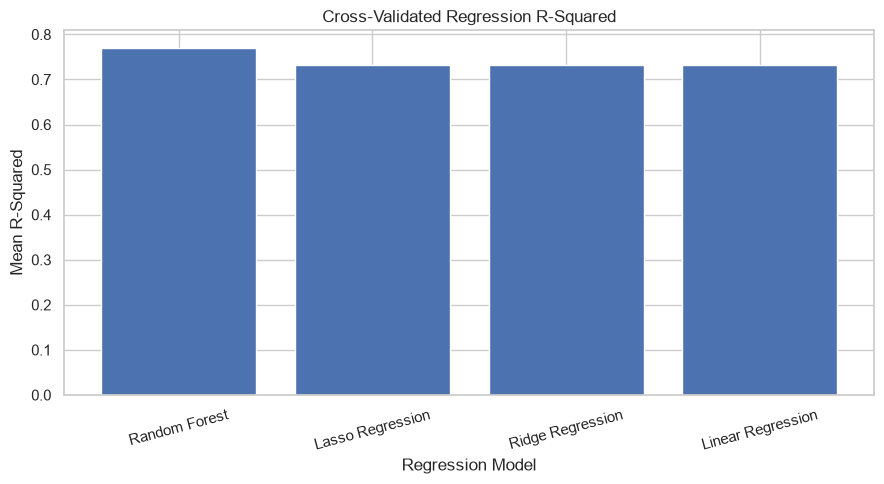

In [17]:
# Compare cross-validated R-squared values.
sorted_regression = regression_comparison.sort_values(
    "CV R2 Mean",
    ascending=False
)

plt.figure(figsize=(9, 5))
plt.bar(
    sorted_regression.index,
    sorted_regression["CV R2 Mean"]
)
plt.title("Cross-Validated Regression R-Squared")
plt.xlabel("Regression Model")
plt.ylabel("Mean R-Squared")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

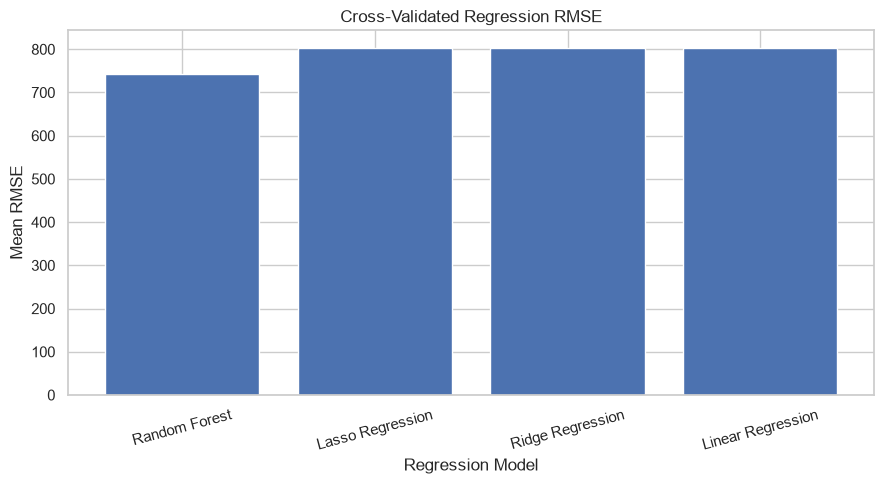

In [18]:
# Compare cross-validated RMSE values.
plt.figure(figsize=(9, 5))
plt.bar(
    sorted_regression.index,
    sorted_regression["CV RMSE Mean"]
)
plt.title("Cross-Validated Regression RMSE")
plt.xlabel("Regression Model")
plt.ylabel("Mean RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

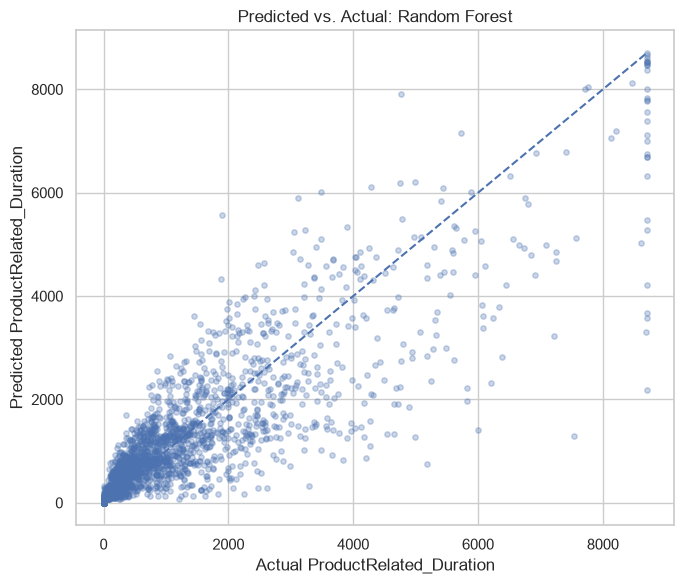

Best regression model: Random Forest


In [19]:
# Display predicted and actual values for the best regression model.
best_regression_name = regression_comparison[
    "CV R2 Mean"
].idxmax()

best_regression_model = regression_results[
    best_regression_name
]["model"]

best_regression_predictions = regression_results[
    best_regression_name
]["predictions"]

plt.figure(figsize=(7, 6))
plt.scatter(
    y_reg_test,
    best_regression_predictions,
    alpha=0.3,
    s=15
)

regression_maximum = max(
    y_reg_test.max(),
    best_regression_predictions.max()
)

plt.plot(
    [0, regression_maximum],
    [0, regression_maximum],
    linestyle="--"
)

plt.title(f"Predicted vs. Actual: {best_regression_name}")
plt.xlabel("Actual ProductRelated_Duration")
plt.ylabel("Predicted ProductRelated_Duration")
plt.tight_layout()
plt.show()

print("Best regression model:", best_regression_name)

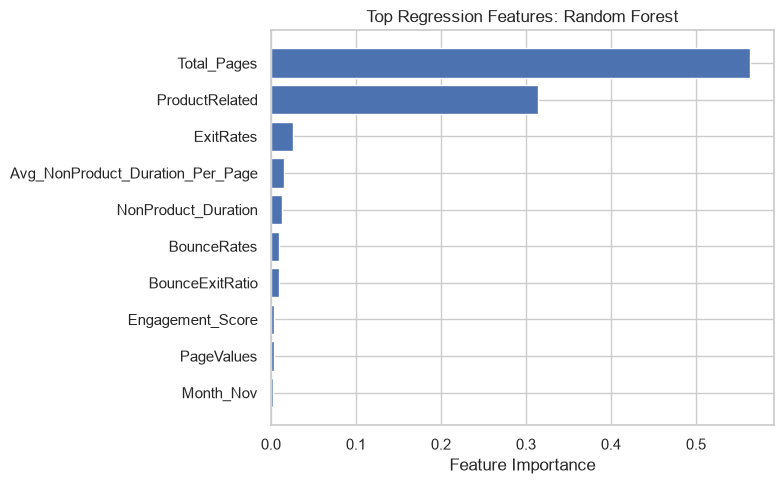

Total_Pages                         0.5637
ProductRelated                      0.3145
ExitRates                           0.0256
Avg_NonProduct_Duration_Per_Page    0.0159
NonProduct_Duration                 0.0127
BounceRates                         0.0099
BounceExitRatio                     0.0093
Engagement_Score                    0.0041
PageValues                          0.0040
Month_Nov                           0.0030
dtype: float64

In [20]:
# Display feature importance for the best regression model.
if best_regression_name == "Random Forest":
    regression_importance = pd.Series(
        best_regression_model.feature_importances_,
        index=X_regression.columns
    ).sort_values(ascending=False).head(10)
else:
    regression_importance = pd.Series(
        np.abs(best_regression_model.coef_),
        index=X_regression.columns
    ).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(
    regression_importance.sort_values().index,
    regression_importance.sort_values().values
)
plt.title(
    f"Top Regression Features: {best_regression_name}"
)
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

regression_importance.round(4)

### Regression Findings

Random Forest was the strongest regression model. In the finalized Deliverable 2 run, it achieved a test R-squared of approximately **0.7506**, a test RMSE of approximately **784.02 seconds**, a cross-validated R-squared of approximately **0.7702**, and a cross-validated RMSE of approximately **742.97 seconds**.

`Total_Pages` and `ProductRelated` page count were the dominant regression features. Random Forest outperforming the linear models indicates that product-related browsing duration contains meaningful non-linear patterns.

# Part 3: Classification and Hyperparameter Tuning

## Classification Feature Preparation

The same five engineered features are recreated. Revenue is now the target, while ProductRelated_Duration remains available as a predictor.

In [21]:
# Create a separate classification copy.
classification_df = data.copy()

classification_df["Total_Pages"] = (
    classification_df["Administrative"]
    + classification_df["Informational"]
    + classification_df["ProductRelated"]
)

classification_df["NonProduct_Duration"] = (
    classification_df["Administrative_Duration"]
    + classification_df["Informational_Duration"]
)

classification_nonproduct_pages = (
    classification_df["Administrative"]
    + classification_df["Informational"]
).replace(0, np.nan)

classification_df["Avg_NonProduct_Duration_Per_Page"] = (
    classification_df["NonProduct_Duration"]
    / classification_nonproduct_pages
).fillna(0)

classification_df["BounceExitRatio"] = (
    classification_df["BounceRates"]
    / (classification_df["ExitRates"] + 0.001)
)

classification_df["Engagement_Score"] = (
    classification_df["ProductRelated"]
    * classification_df["PageValues"]
)

classification_df["Weekend"] = (
    classification_df["Weekend"].astype(int)
)
classification_df["Revenue"] = (
    classification_df["Revenue"].astype(int)
)

for column in [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]:
    classification_df[column] = (
        classification_df[column].astype(str)
    )

classification_df = pd.get_dummies(
    classification_df,
    columns=[
        "Month",
        "VisitorType",
        "OperatingSystems",
        "Browser",
        "Region",
        "TrafficType"
    ],
    drop_first=True,
    dtype=int
)

classification_target = "Revenue"

classification_columns_to_remove = [
    classification_target,
    "Administrative",
    "Informational",
    "Administrative_Duration",
    "Informational_Duration"
]

X_classification = classification_df.drop(
    columns=classification_columns_to_remove
)
y_classification = classification_df[
    classification_target
]

X_cls_train, X_cls_test, y_cls_train, y_cls_test = (
    train_test_split(
        X_classification,
        y_classification,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_classification
    )
)

print("Classification feature matrix:", X_classification.shape)
print("Classification training set:", X_cls_train.shape)
print("Classification test set:", X_cls_test.shape)
print("Training purchase rate:", round(y_cls_train.mean(), 4))
print("Test purchase rate:", round(y_cls_test.mean(), 4))

Classification feature matrix: (12205, 69)
Classification training set: (9764, 69)
Classification test set: (2441, 69)
Training purchase rate: 0.1563
Test purchase rate: 0.1565


## Classification Models

Two models are evaluated:

1. Logistic Regression with standardized predictors and balanced class weights
2. Random Forest Classifier with balanced class weights and GridSearchCV tuning

F1 score is used as the tuning objective because purchases represent the minority class.

In [22]:
# Train a classifier and calculate test metrics.
classification_results = {}

def evaluate_classifier(
    name,
    model,
    X_test_data,
    y_test_data
):
    predictions = model.predict(X_test_data)
    probabilities = model.predict_proba(
        X_test_data
    )[:, 1]

    metrics = {
        "Accuracy": accuracy_score(
            y_test_data,
            predictions
        ),
        "F1 Score": f1_score(
            y_test_data,
            predictions
        ),
        "ROC-AUC": roc_auc_score(
            y_test_data,
            probabilities
        )
    }

    classification_results[name] = {
        "model": model,
        "predictions": predictions,
        "probabilities": probabilities,
        **metrics
    }

    print(
        f"{name}: "
        f"Accuracy = {metrics['Accuracy']:.4f}, "
        f"F1 = {metrics['F1 Score']:.4f}, "
        f"ROC-AUC = {metrics['ROC-AUC']:.4f}"
    )

    print()
    print(classification_report(
        y_test_data,
        predictions,
        target_names=[
            "No Purchase",
            "Purchase"
        ]
    ))

In [23]:
# Train the Logistic Regression baseline.
logistic_classifier = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

logistic_classifier.fit(
    X_cls_train,
    y_cls_train
)

evaluate_classifier(
    "Logistic Regression",
    logistic_classifier,
    X_cls_test,
    y_cls_test
)

Logistic Regression: Accuracy = 0.8484, F1 = 0.6255, ROC-AUC = 0.9084

              precision    recall  f1-score   support

 No Purchase       0.96      0.86      0.90      2059
    Purchase       0.51      0.81      0.63       382

    accuracy                           0.85      2441
   macro avg       0.74      0.83      0.77      2441
weighted avg       0.89      0.85      0.86      2441



In [24]:
# Tune the Random Forest using focused, stratified grid search.
classification_parameter_grid = {
    "max_depth": [8, 12],
    "min_samples_leaf": [1, 3],
    "min_samples_split": [2],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"]
}

classification_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

classification_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        n_estimators=150,
        random_state=RANDOM_STATE,
        n_jobs=1
    ),
    param_grid=classification_parameter_grid,
    scoring="f1",
    cv=classification_cv,
    n_jobs=1
)

classification_grid_search.fit(
    X_cls_train,
    y_cls_train
)

print(
    "Best parameters:",
    classification_grid_search.best_params_
)
print(
    "Best cross-validated F1:",
    round(
        classification_grid_search.best_score_,
        4
    )
)

Best parameters: {'class_weight': 'balanced', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validated F1: 0.6679


In [25]:
# Evaluate the tuned Random Forest on the held-out test set.
tuned_random_forest = (
    classification_grid_search.best_estimator_
)

evaluate_classifier(
    "Tuned Random Forest",
    tuned_random_forest,
    X_cls_test,
    y_cls_test
)

Tuned Random Forest: Accuracy = 0.8751, F1 = 0.6745, ROC-AUC = 0.9341

              precision    recall  f1-score   support

 No Purchase       0.97      0.88      0.92      2059
    Purchase       0.57      0.83      0.67       382

    accuracy                           0.88      2441
   macro avg       0.77      0.86      0.80      2441
weighted avg       0.90      0.88      0.88      2441



## Classification Model Comparison

In [26]:
classification_comparison = pd.DataFrame({
    name: {
        "Accuracy": values["Accuracy"],
        "F1 Score": values["F1 Score"],
        "ROC-AUC": values["ROC-AUC"]
    }
    for name, values in classification_results.items()
}).T

classification_comparison.round(4)

,Accuracy,F1 Score,ROC-AUC
Logistic Regression,0.8484,0.6255,0.9084
Tuned Random Forest,0.8751,0.6745,0.9341


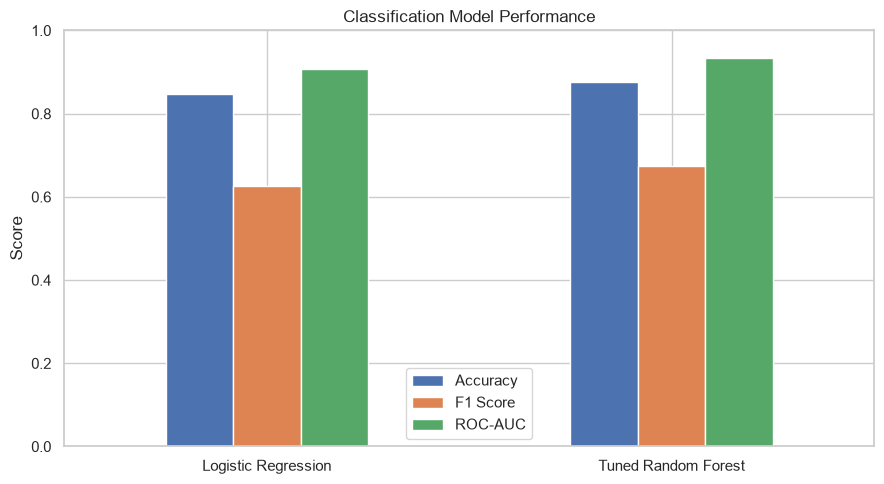

In [27]:
# Compare the three classification metrics.
classification_plot = classification_comparison[
    ["Accuracy", "F1 Score", "ROC-AUC"]
]

classification_plot.plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title("Classification Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Confusion Matrices

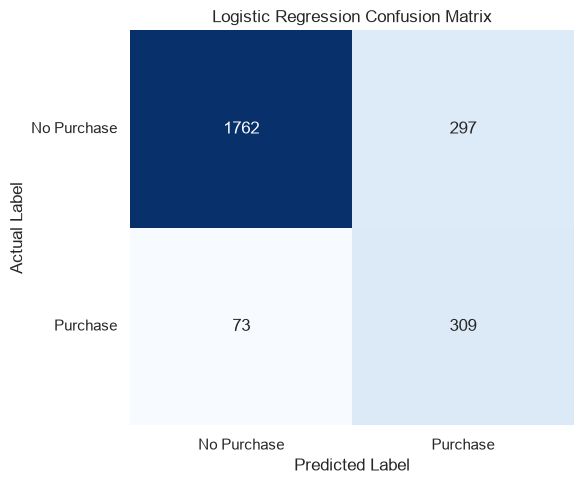

In [28]:
# Display the Logistic Regression confusion matrix.
logistic_matrix = confusion_matrix(
    y_cls_test,
    classification_results[
        "Logistic Regression"
    ]["predictions"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    logistic_matrix,
    annot=True,
    fmt="d",
    cbar=False,
    cmap="Blues"
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(
    [0.5, 1.5],
    ["No Purchase", "Purchase"]
)
plt.yticks(
    [0.5, 1.5],
    ["No Purchase", "Purchase"],
    rotation=0
)
plt.tight_layout()
plt.show()

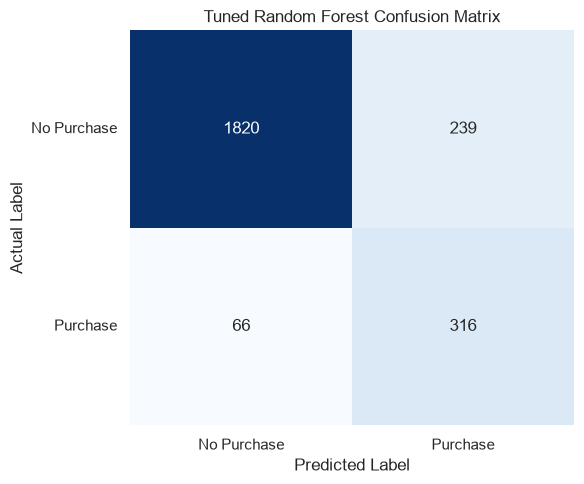

In [29]:
# Display the tuned Random Forest confusion matrix.
random_forest_matrix = confusion_matrix(
    y_cls_test,
    classification_results[
        "Tuned Random Forest"
    ]["predictions"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    random_forest_matrix,
    annot=True,
    fmt="d",
    cbar=False,
    cmap="Blues"
)
plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(
    [0.5, 1.5],
    ["No Purchase", "Purchase"]
)
plt.yticks(
    [0.5, 1.5],
    ["No Purchase", "Purchase"],
    rotation=0
)
plt.tight_layout()
plt.show()

## ROC Curves

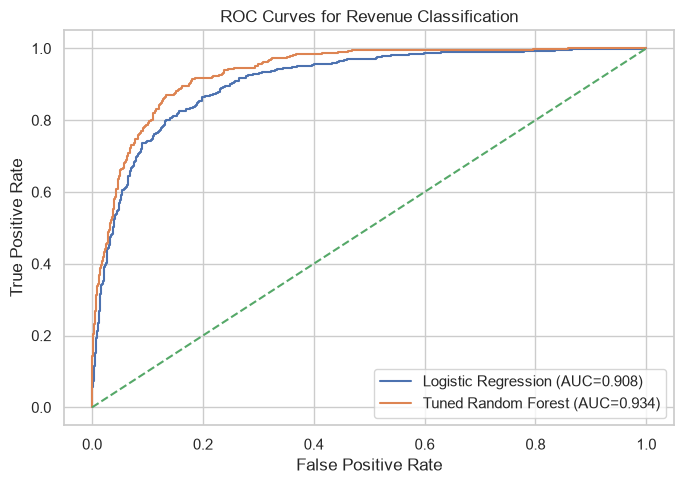

In [30]:
# Compare ROC curves for both classifiers.
plt.figure(figsize=(7, 5))

for name, values in classification_results.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_cls_test,
        values["probabilities"]
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=(
            f"{name} "
            f"(AUC={values['ROC-AUC']:.3f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Revenue Classification")
plt.legend()
plt.tight_layout()
plt.show()

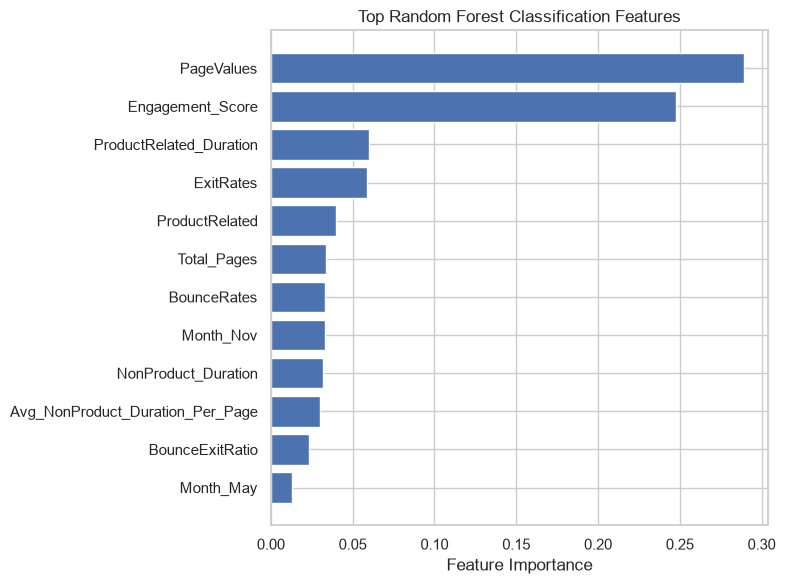

PageValues                          0.2895
Engagement_Score                    0.2474
ProductRelated_Duration             0.0601
ExitRates                           0.0586
ProductRelated                      0.0396
Total_Pages                         0.0335
BounceRates                         0.0331
Month_Nov                           0.0331
NonProduct_Duration                 0.0320
Avg_NonProduct_Duration_Per_Page    0.0302
BounceExitRatio                     0.0234
Month_May                           0.0127
dtype: float64

In [31]:
# Display the most influential tuned Random Forest features.
classification_importance = pd.Series(
    tuned_random_forest.feature_importances_,
    index=X_classification.columns
).sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 6))
plt.barh(
    classification_importance.sort_values().index,
    classification_importance.sort_values().values
)
plt.title("Top Random Forest Classification Features")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

classification_importance.round(4)

### Classification Findings

The tuned Random Forest was the strongest classifier. In the finalized Deliverable 3 run, it achieved:

- Accuracy: **0.8759**
- F1 score: **0.6759**
- ROC-AUC: **0.9340**

It correctly identified **316 purchasing sessions**, missed **66**, and produced fewer false positives than Logistic Regression.

`PageValues` and `Engagement_Score` were the two most influential classification features. The stronger Random Forest results again demonstrate that shopping behavior contains non-linear relationships.

# Part 4: K-Means Clustering

Revenue is excluded from clustering. Nine standardized behavioral variables are used to identify groups of shopping sessions with similar behavior.

Silhouette scores are calculated using a reproducible sample of 3,000 sessions to reduce computation time. The final K-Means model is fitted to the complete dataset.

In [32]:
cluster_features = [
    "Administrative",
    "Informational",
    "ProductRelated",
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

cluster_data = data[cluster_features].copy()

cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(
    cluster_data
)

silhouette_scores = {}

for number_of_clusters in range(2, 6):
    cluster_candidate = KMeans(
        n_clusters=number_of_clusters,
        n_init=20,
        random_state=RANDOM_STATE
    )

    candidate_labels = (
        cluster_candidate.fit_predict(
            cluster_scaled
        )
    )

    silhouette_scores[number_of_clusters] = (
        silhouette_score(
            cluster_scaled,
            candidate_labels,
            sample_size=3000,
            random_state=RANDOM_STATE
        )
    )

pd.Series(
    silhouette_scores,
    name="Silhouette Score"
).round(4)

2    0.4658
3    0.4885
4    0.4025
5    0.4418
Name: Silhouette Score, dtype: float64

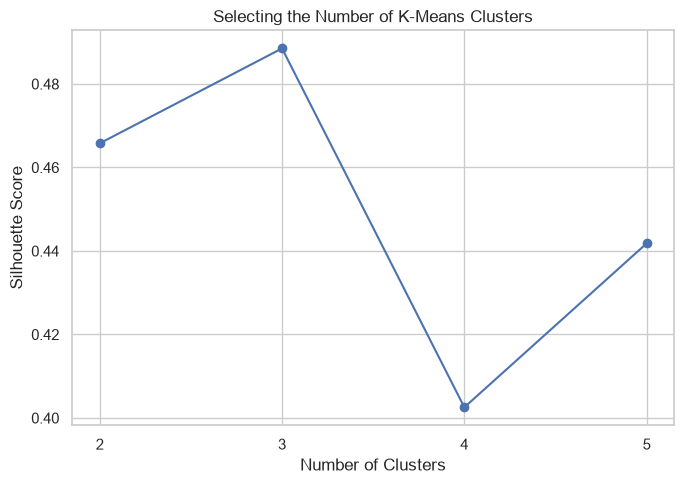

In [33]:
# Plot the silhouette score for each candidate cluster count.
plt.figure(figsize=(7, 5))
plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)
plt.xticks(list(silhouette_scores.keys()))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Selecting the Number of K-Means Clusters")
plt.tight_layout()
plt.show()

In [34]:
# Fit the final K-Means model using the best cluster count.
best_cluster_count = max(
    silhouette_scores,
    key=silhouette_scores.get
)

kmeans_model = KMeans(
    n_clusters=best_cluster_count,
    n_init=20,
    random_state=RANDOM_STATE
)

final_cluster_labels = kmeans_model.fit_predict(
    cluster_scaled
)

clustered_data = data.copy()
clustered_data["Cluster"] = final_cluster_labels

cluster_profile = clustered_data.groupby(
    "Cluster"
).agg(
    Sessions=("Revenue", "size"),
    Purchase_Rate=("Revenue", "mean"),
    Administrative=("Administrative", "mean"),
    Informational=("Informational", "mean"),
    ProductRelated=("ProductRelated", "mean"),
    ProductRelated_Duration=(
        "ProductRelated_Duration",
        "mean"
    ),
    BounceRates=("BounceRates", "mean"),
    ExitRates=("ExitRates", "mean"),
    PageValues=("PageValues", "mean")
)

cluster_profile["Dataset_Share"] = (
    cluster_profile["Sessions"]
    / len(clustered_data)
)

print("Selected number of clusters:", best_cluster_count)
cluster_profile.round(3)

Selected number of clusters: 3


,Sessions,Purchase_Rate,Administrative,Informational,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,Dataset_Share
Cluster,,,,,,,,,,
0,9430,0.147,1.624,0.202,23.180,842.417,0.009,0.032,5.802,0.773
1,920,0.007,0.054,0.017,3.215,63.119,0.162,0.178,0.000,0.075
2,1855,0.278,7.107,2.313,91.412,3348.643,0.006,0.020,9.653,0.152


## PCA Cluster Visualization

PCA is used only to reduce the nine clustering variables to two dimensions for visualization. K-Means itself remains fitted on all nine standardized variables.

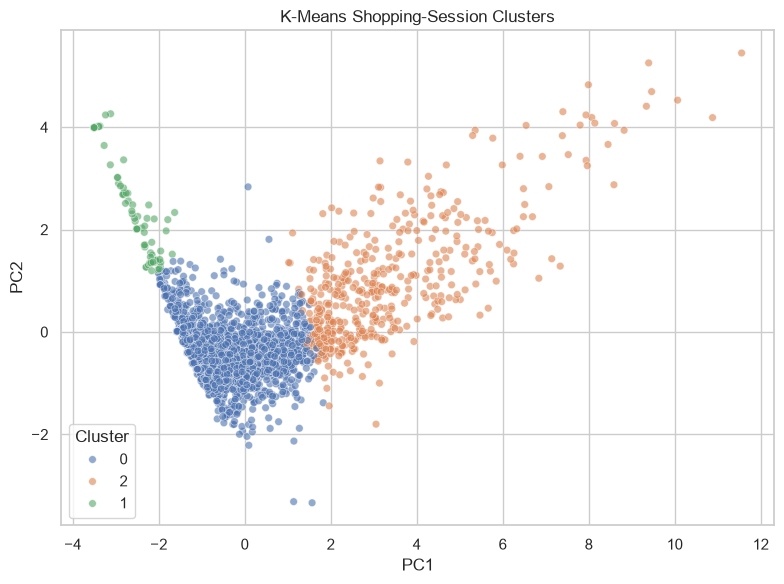

Variance explained by two PCA components: 0.5654


In [35]:
pca = PCA(n_components=2)
cluster_coordinates = pca.fit_transform(
    cluster_scaled
)

cluster_plot = pd.DataFrame({
    "PC1": cluster_coordinates[:, 0],
    "PC2": cluster_coordinates[:, 1],
    "Cluster": final_cluster_labels.astype(str)
})

cluster_plot_sample = cluster_plot.sample(
    n=min(3000, len(cluster_plot)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=cluster_plot_sample,
    x="PC1",
    y="PC2",
    hue="Cluster",
    alpha=0.6,
    s=30
)
plt.title("K-Means Shopping-Session Clusters")
plt.tight_layout()
plt.show()

print(
    "Variance explained by two PCA components:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

### Cluster Findings

The three-cluster solution produced the highest silhouette score of **0.4885**.

- **Cluster 0 – Typical browsing sessions:** 9,430 sessions, 77.3% of the dataset, and a 14.7% purchase rate.
- **Cluster 1 – Quick-exit sessions:** 920 sessions, high bounce and exit rates, and a purchase rate of only 0.7%.
- **Cluster 2 – Highly engaged sessions:** 1,855 sessions, high product-page activity, and a 27.8% purchase rate.

The labels are identifiers rather than rankings. The behavioral profiles give the clusters their practical meaning.

# Part 5: Association Rule Mining

The dataset contains session behavior rather than traditional product baskets. Session measures are therefore converted into Boolean items using a combination of median-based thresholds and existing categorical conditions.

In [36]:
# Convert selected session behaviors into Boolean items.
association_basket = pd.DataFrame(
    index=data.index
)

association_basket["High_Product_Pages"] = (
    data["ProductRelated"]
    > data["ProductRelated"].median()
)

association_basket["Long_Product_Duration"] = (
    data["ProductRelated_Duration"]
    > data["ProductRelated_Duration"].median()
)

association_basket["Positive_PageValues"] = (
    data["PageValues"] > 0
)

association_basket["Low_Bounce_Rate"] = (
    data["BounceRates"]
    <= data["BounceRates"].median()
)

association_basket["Low_Exit_Rate"] = (
    data["ExitRates"]
    <= data["ExitRates"].median()
)

association_basket["Returning_Visitor"] = (
    data["VisitorType"] == "Returning_Visitor"
)

association_basket["New_Visitor"] = (
    data["VisitorType"] == "New_Visitor"
)

association_basket["Weekend"] = (
    data["Weekend"].astype(bool)
)

association_basket["November"] = (
    data["Month"].eq("Nov")
)

association_basket["Special_Day_Visit"] = (
    data["SpecialDay"] > 0
)

association_basket["Purchase"] = (
    data["Revenue"].astype(bool)
)

association_basket.mean().sort_values(
    ascending=False
).round(4)

Returning_Visitor        0.8546
Low_Exit_Rate            0.5035
Low_Bounce_Rate          0.5003
Long_Product_Duration    0.5000
High_Product_Pages       0.4949
November                 0.2443
Weekend                  0.2342
Positive_PageValues      0.2237
Purchase                 0.1563
New_Visitor              0.1387
Special_Day_Visit        0.1023
dtype: float64

In [37]:
# Implement a compact Apriori search for frequent itemsets.
def apriori_frequent_itemsets(
    binary_data,
    min_support=0.05,
    max_length=4
):
    frequent_supports = {}

    # Identify frequent individual items.
    current_level = []

    for column in binary_data.columns:
        itemset = frozenset([column])
        support = binary_data[column].mean()

        if support >= min_support:
            frequent_supports[itemset] = support
            current_level.append(itemset)

    # Create higher-order candidates using the Apriori property.
    for itemset_length in range(
        2,
        max_length + 1
    ):
        candidate_items = sorted(
            set().union(*current_level)
        )

        candidates = []

        for candidate_tuple in combinations(
            candidate_items,
            itemset_length
        ):
            candidate = frozenset(candidate_tuple)

            all_subsets_frequent = all(
                frozenset(subset)
                in frequent_supports
                for subset in combinations(
                    candidate_tuple,
                    itemset_length - 1
                )
            )

            if all_subsets_frequent:
                candidates.append(candidate)

        next_level = []

        for candidate in candidates:
            support = binary_data[
                list(candidate)
            ].all(axis=1).mean()

            if support >= min_support:
                frequent_supports[
                    candidate
                ] = support
                next_level.append(candidate)

        if not next_level:
            break

        current_level = next_level

    return frequent_supports


frequent_itemsets = apriori_frequent_itemsets(
    association_basket,
    min_support=0.05,
    max_length=4
)

print(
    "Number of frequent itemsets:",
    len(frequent_itemsets)
)

Number of frequent itemsets: 161


In [38]:
# Generate rules that have Purchase as the consequent.
purchase_support = frequent_itemsets[
    frozenset(["Purchase"])
]

purchase_rules = []

for itemset, support in frequent_itemsets.items():

    if (
        "Purchase" not in itemset
        or len(itemset) < 2
    ):
        continue

    antecedent = itemset - {"Purchase"}

    antecedent_support = association_basket[
        list(antecedent)
    ].all(axis=1).mean()

    confidence = support / antecedent_support
    lift = confidence / purchase_support

    purchase_rules.append({
        "Antecedent": " & ".join(
            sorted(antecedent)
        ),
        "Support": support,
        "Confidence": confidence,
        "Lift": lift
    })

rules_table = pd.DataFrame(purchase_rules)

meaningful_rules = (
    rules_table[
        (rules_table["Confidence"] >= 0.30)
        & (rules_table["Lift"] >= 1.20)
    ]
    .sort_values(
        ["Lift", "Confidence", "Support"],
        ascending=False
    )
    .reset_index(drop=True)
)

meaningful_rules.head(10).round(4)

,Antecedent,Support,Confidence,Lift
0,Low_Bounce_Rate & Low_Exit_Rate & Positive_Pag...,0.0738,0.6800,4.3498
1,Low_Bounce_Rate & Positive_PageValues,0.0818,0.6757,4.3222
2,Long_Product_Duration & Low_Bounce_Rate & Posi...,0.0560,0.6170,3.9467
3,Low_Exit_Rate & Positive_PageValues,0.1014,0.6126,3.9184
4,Low_Bounce_Rate & Positive_PageValues & Return...,0.0556,0.6097,3.9002
5,High_Product_Pages & Low_Bounce_Rate & Positiv...,0.0511,0.5943,3.8015
6,Long_Product_Duration & Low_Exit_Rate & Positi...,0.0782,0.5685,3.6362
7,Positive_PageValues,0.1260,0.5634,3.6037
8,Low_Exit_Rate & Positive_PageValues & Returnin...,0.0754,0.5569,3.5624
9,High_Product_Pages & Low_Exit_Rate & Positive_...,0.0752,0.5527,3.5354


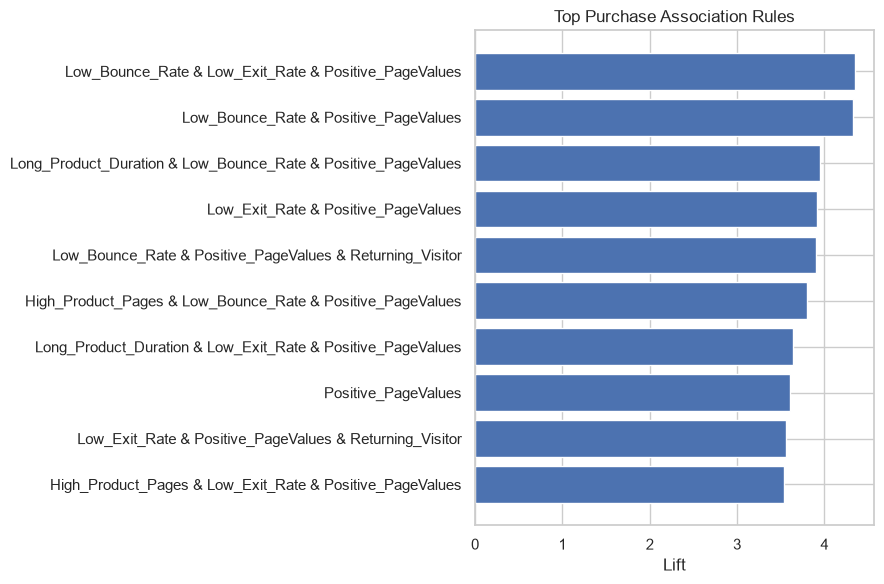

In [39]:
# Visualize the top association rules by lift.
top_rules = meaningful_rules.head(10).copy()
top_rules = top_rules.sort_values("Lift")

plt.figure(figsize=(9, 6))
plt.barh(
    top_rules["Antecedent"],
    top_rules["Lift"]
)
plt.xlabel("Lift")
plt.title("Top Purchase Association Rules")
plt.tight_layout()
plt.show()

### Association Rule Findings

Apriori identified **161 frequent itemsets**.

The strongest rule combined:

- Positive PageValues
- Low bounce rate
- Low exit rate

This pattern had approximately **7.38% support**, **68.00% confidence**, and a **lift of 4.35**. Sessions matching the rule purchased at more than four times the overall purchase rate.

Positive PageValues alone also produced a strong rule, confirming that it remained the most consistent purchase-intent signal across the project.

Association rules describe co-occurrence and do not establish causation.

# Part 6: Integrated Project Findings

In [40]:
# Create one concise table summarizing the strongest results.
best_regression_row = regression_comparison.loc[
    best_regression_name
]

best_classification_name = (
    classification_comparison["F1 Score"].idxmax()
)
best_classification_row = (
    classification_comparison.loc[
        best_classification_name
    ]
)

strongest_rule = meaningful_rules.iloc[0]

integrated_summary = pd.DataFrame({
    "Project Stage": [
        "Data preparation",
        "Regression",
        "Classification",
        "Clustering",
        "Association rules"
    ],
    "Best Result": [
        (
            f"{len(data):,} cleaned sessions; "
            f"{data['Revenue'].mean() * 100:.2f}% purchase rate"
        ),
        (
            f"{best_regression_name}: "
            f"Test R2={best_regression_row['Test R2']:.4f}, "
            f"CV R2={best_regression_row['CV R2 Mean']:.4f}"
        ),
        (
            f"{best_classification_name}: "
            f"F1={best_classification_row['F1 Score']:.4f}, "
            f"ROC-AUC={best_classification_row['ROC-AUC']:.4f}"
        ),
        (
            f"{best_cluster_count} clusters; "
            f"best silhouette={silhouette_scores[best_cluster_count]:.4f}"
        ),
        (
            f"Strongest purchase rule lift="
            f"{strongest_rule['Lift']:.4f}"
        )
    ]
})

integrated_summary

,Project Stage,Best Result
0,Data preparation,"12,205 cleaned sessions; 15.63% purchase rate"
1,Regression,"Random Forest: Test R2=0.7506, CV R2=0.7702"
2,Classification,"Tuned Random Forest: F1=0.6745, ROC-AUC=0.9341"
3,Clustering,3 clusters; best silhouette=0.4885
4,Association rules,Strongest purchase rule lift=4.3498


## Major Integrated Insights

1. **Page value is the most consistent purchase signal.** It had the strongest correlation with Revenue, was the most influential classification feature, and appeared in the strongest association rules.

2. **Browsing depth predicts engagement.** Total page count and product-page count were the most important predictors of product-related duration.

3. **Purchase behavior is non-linear.** Random Forest outperformed the linear regression and classification baselines.

4. **Low abandonment is associated with conversion.** Lower bounce and exit rates appeared in EDA, classification importance, cluster profiles, and association rules.

5. **Shopping sessions form meaningful behavioral groups.** Quick-exit sessions rarely purchased, while highly engaged sessions had a purchase rate of approximately 27.8%.

6. **The minority purchase class requires careful evaluation.** F1 score, ROC-AUC, stratification, and confusion matrices provided more meaningful evaluation than accuracy alone.

# Part 7: Practical Recommendations

Based on the consolidated findings, an online retailer could take the following actions:

- **Prioritize high-intent sessions:** When the necessary behavioral features are available, use the tuned classifier to identify sessions that may benefit from assistance, targeted offers, or remarketing.
- **Improve quick-exit experiences:** Simplify landing pages, improve page speed, clarify navigation, and shorten the path to relevant products.
- **Support highly engaged visitors:** Provide product recommendations, comparison tools, saved carts, and carefully timed promotions.
- **Use abandonment signals:** Treat positive PageValues combined with low bounce and exit behavior as a strong high-intent pattern.
- **Plan seasonal campaigns:** The elevated November conversion rate can support promotional timing and inventory planning.
- **Monitor models after deployment:** Track F1 score, false positives, false negatives, calibration, and changes in customer behavior over time.

# Project Challenges and Resolutions

Several challenges were encountered throughout the project.

- **Selecting a regression target:** PageValues was initially considered but was zero for approximately 77.6% of sessions. ProductRelated_Duration was selected because it behaved more like a continuous outcome.

- **Handling duplicate and extreme observations:** The original dataset contained 125 exact duplicate records. These were removed, while extreme duration values were capped at their 99th-percentile limits instead of deleting complete sessions.

- **Categorical codes stored as numbers:** Browser, OperatingSystems, Region, and TrafficType were numerical category labels rather than continuous measurements. They were converted and one-hot encoded before modeling.

- **Preventing target and preprocessing leakage:** Revenue was excluded from regression, and engineered regression features did not directly use ProductRelated_Duration. Scaling was fitted only on training data and was placed inside cross-validation pipelines.

- **Class imbalance:** Only 15.63% of sessions resulted in purchases. Stratified splitting, balanced class weights, F1 score, confusion matrices, and ROC-AUC were used to evaluate classification performance more appropriately.

- **Modeling non-linear behavior:** Linear models provided useful baselines, but Random Forest performed better in both regression and classification. This showed that important browsing relationships were partly non-linear.

- **Computational cost:** Focused hyperparameter grids and a reproducible sample of 3,000 sessions for silhouette analysis reduced runtime while preserving meaningful comparisons.

- **Cluster interpretation:** K-Means produced numerical cluster labels without business meaning. Cluster averages, dataset shares, and purchase rates were used to identify typical, quick-exit, and highly engaged sessions.

- **Association-rule preparation:** The dataset contained session behavior rather than traditional shopping baskets. Continuous measurements were converted into transparent Boolean conditions before applying Apriori.

- **Avoiding causal claims:** Feature importance, cluster membership, and association rules were interpreted as patterns rather than proof that a specific behavior causes a purchase.

# Part 8: Ethical Considerations

## Data Privacy

Browsing behavior may reveal personal preferences and purchasing intent. Organizations should minimize the data collected, remove direct identifiers, protect stored session information, and limit access to authorized personnel.

## Fairness and Potential Bias

Region, browser, operating system, traffic source, and visitor type may act as indirect proxies for socioeconomic or demographic differences. Model performance should be evaluated across meaningful user groups before decisions are automated.

## Class-Imbalance Effects

Because purchases are the minority outcome, model errors are not evenly distributed. False negatives may overlook customers who would purchase, while false positives may expose non-purchasing visitors to unnecessary or intrusive targeting.

## Transparency and Causality

Feature importance, clustering, and association rules identify patterns rather than causes. Results should be communicated as probabilities and behavioral relationships rather than deterministic explanations.

## Responsible Personalization

Predictive outputs should support customer experience rather than manipulate users. Offers and recommendations should remain transparent, relevant, and easy to decline.

## Data Retention and Security

Session-level data should be retained only as long as necessary. Appropriate encryption, access controls, monitoring, and deletion policies should be used.

# Part 9: Project Limitations

- The dataset represents sessions rather than identified customers, so repeated visits by the same person cannot be studied.
- The dataset does not contain product-level transaction baskets, limiting the interpretation of association rules.
- January and April are absent, so the monthly analysis is not a complete twelve-month seasonal study.
- PageValues may not be available early enough in a live session for every real-time application.
- The models were evaluated on one historical dataset and may not generalize to different websites, industries, or time periods.
- K-Means assumes compact cluster shapes and requires the number of clusters to be selected in advance.
- Median-based association thresholds are transparent but may not be optimal for every business setting.
- Feature importance does not establish causality.

# Part 10: Future Improvements

Future work could:

- Compare Gradient Boosting or other advanced ensemble models
- Tune classification thresholds based on business costs
- Evaluate probability calibration
- Use SHAP or other explainability methods
- Apply time-based validation to measure model drift
- Compare K-Means with Hierarchical or DBSCAN clustering
- Use product-level transaction data for traditional market-basket analysis
- Evaluate fairness and performance across visitor groups
- Test the models on another retailer or a more recent dataset

# Conclusion

This project applied a complete data-mining workflow to 12,205 online shopping sessions.

Deliverable 1 established data quality and identified meaningful behavioral relationships. Deliverable 2 showed that Random Forest was the strongest model for predicting product-related browsing duration. Deliverable 3 showed that a tuned Random Forest was also the strongest purchase classifier, while K-Means identified three useful behavioral session groups and Apriori discovered high-intent behavioral patterns.

Across all analyses, PageValues, product engagement, and low abandonment behavior were the most consistent indicators of purchasing intent. The findings can support website design, marketing prioritization, customer segmentation, and seasonal planning when used carefully.

The models and patterns should remain decision-support tools. Responsible use requires privacy protection, fairness evaluation, transparency, ongoing monitoring, and recognition that statistical relationships do not prove causation.

# References

Han, J., Pei, J., & Tong, H. (2022). *Data mining* (4th ed.). Elsevier.

Sakar, C., & Kastro, Y. (2018). *Online Shoppers Purchasing Intention Dataset* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q

Wu, D. (2024). *Data mining with Python*. Taylor & Francis.